# Automotive Part Image-Text Matching — Dataset V4

## Final exam report

This is my main report for Dataset V4. I use the results that I already saved during the experiments. I do **not** train a new model here and I do **not** run the final test again.

The task has three labels:

- `MATCH`
- `PARTIAL_MATCH`
- `MISMATCH`

My main question is simple: can a model that uses both an automotive-part image and a short text description classify their relation better than models that use only one input?


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path('.').resolve()
RESULT_DIR = PROJECT_ROOT / 'results' / 'dataset_v4'
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'manifests' / 'dataset_v4' / 'images.csv'
AUDIT_PATH = PROJECT_ROOT / 'data' / 'manifests' / 'dataset_v4' / 'dataset_audit.json'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
print('Project root:', PROJECT_ROOT)

Project root: C:\Users\stana\Desktop\automotive-part-image-text-matching-sat


## 1. Load the saved Dataset V4 results

I load the saved validation results, final-test predictions, final-test summary, and the extra checks that I made after seeing the high final score. I do not execute the final-test model in this notebook.


In [2]:
manifest = pd.read_csv(MANIFEST_PATH)
dataset_audit = json.loads(AUDIT_PATH.read_text(encoding='utf-8'))
validation_summary = json.loads((RESULT_DIR / 'step03_validation_summary.json').read_text(encoding='utf-8'))
validation_history = pd.read_csv(RESULT_DIR / 'step03_training_history.csv')
final_summary = json.loads((RESULT_DIR / 'step04_final_test_summary.json').read_text(encoding='utf-8'))
final_predictions = pd.read_csv(RESULT_DIR / 'step04_final_test_predictions.csv')
sanity_audit = json.loads((RESULT_DIR / 'step04_sanity_audit.json').read_text(encoding='utf-8'))
error_rows = pd.read_csv(RESULT_DIR / 'step04_error_rows.csv')
error_summary = pd.read_csv(RESULT_DIR / 'step04_error_summary.csv')

print('Validation status:', validation_summary['status'])
print('Final-test status:', final_summary['status'])
print('Sanity-audit status:', sanity_audit['status'])

Validation status: PASS_DATASET_V4_VALIDATION_EXPERIMENTS
Final-test status: PASS_DATASET_V4_FINAL_TEST_EVALUATED
Sanity-audit status: PASS_WITH_NEAR_DUPLICATE_WARNING


## 2. Dataset overview

I used 9,239 independent images from 50 categories. I created the image split first and then created several image-text pairs for each image. This is why the number of relation rows is larger than the number of images.


In [3]:
split_images = manifest['split'].value_counts().reindex(['train', 'validation', 'test'])
relation_rows = pd.Series({
    'train': dataset_audit['relation_summary']['train']['rows'],
    'validation': dataset_audit['relation_summary']['validation']['rows'],
    'test': dataset_audit['relation_summary']['test']['rows'],
})

overview = pd.DataFrame({
    'independent_images': split_images.astype(int),
    'relation_rows': relation_rows.astype(int),
})
overview.loc['TOTAL', 'independent_images'] = int(split_images.sum())
overview.loc['TOTAL', 'relation_rows'] = int(relation_rows.sum())
display(overview.astype(int))

print('Categories:', manifest['part_category'].nunique())
print('Functional families:', manifest['part_family'].nunique())
print('Unique SHA-256:', manifest['sha256'].nunique())

category_counts = manifest['part_category'].value_counts()
print('Images per category range:', int(category_counts.min()), 'to', int(category_counts.max()))

,independent_images,relation_rows
train,6463,41742
validation,1388,9030
test,1388,9030
TOTAL,9239,59802


Categories: 50
Functional families: 12
Unique SHA-256: 9239
Images per category range: 120 to 210


## 3. Image distribution

Here I show how many independent images I have in each part category. The split is approximately 70% train, 15% validation, and 15% final test.


## 4. Validation model comparison

I used validation macro F1 to compare the models, with validation accuracy only as a tie-breaker. The text-only and image-only baselines should be close to chance because the answer depends on the relation between the two balanced inputs.


In [4]:
validation_models = pd.DataFrame([
    {
        'model': item['name'],
        'best_epoch': item['best_epoch'],
        'validation_accuracy': item['validation_accuracy'],
        'validation_macro_f1': item['validation_macro_f1'],
    }
    for item in validation_summary['models']
]).sort_values('validation_macro_f1', ascending=False)

display(validation_models.reset_index(drop=True))
print('Selected model:', validation_summary['selected_model'])
print('Selected best epoch:', validation_summary['selected_best_epoch'])

,model,best_epoch,validation_accuracy,validation_macro_f1
0,multimodal_auxiliary,7,0.897453,0.895793
1,multimodal_no_auxiliary,8,0.862237,0.859170
2,text_only,5,0.333333,0.304181
3,image_only,2,0.333333,0.300306


Selected model: multimodal_auxiliary
Selected best epoch: 7


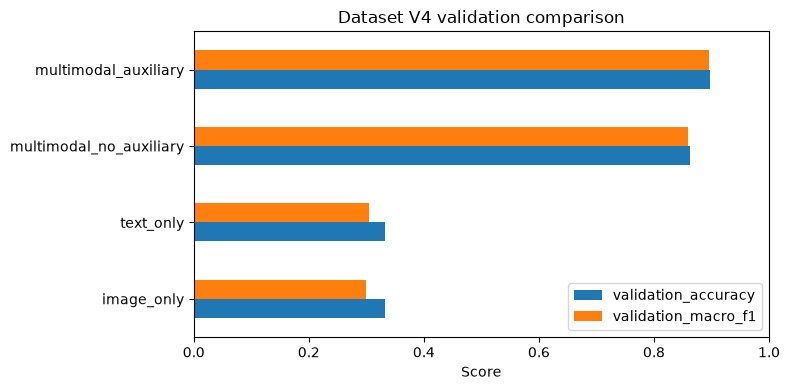

In [5]:
plot_table = validation_models.sort_values('validation_macro_f1')
ax = plot_table.plot.barh(
    x='model',
    y=['validation_accuracy', 'validation_macro_f1'],
    figsize=(8, 4),
)
ax.set_xlim(0, 1)
ax.set_xlabel('Score')
ax.set_ylabel('')
ax.set_title('Dataset V4 validation comparison')
plt.tight_layout()
plt.show()

### Validation experiment history

The next plot shows the validation experiments. At this point the final test was still locked and had not been used.


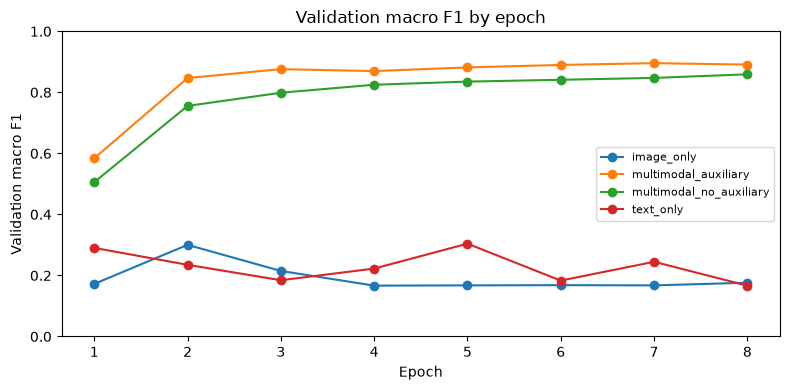

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
for model_name, frame in validation_history.groupby('model'):
    ax.plot(frame['epoch'], frame['validation_macro_f1'], marker='o', label=model_name)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation macro F1')
ax.set_ylim(0, 1)
ax.set_title('Validation macro F1 by epoch')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Saved final-test result

I selected `multimodal_auxiliary` at epoch 7 before opening the final test. I also fixed the evaluation code first. Then I trained the selected model on train + validation for the already chosen 7 epochs and evaluated the locked final test once. I did not tune the model after seeing the test result.

The final result is about **95.4% accuracy** and **95.4% macro F1** on this experiment.

For reference:

\[
\text{Accuracy} = \frac{\text{correct predictions}}{\text{all predictions}}
\]

Macro F1 is the average of the F1 scores for the three relation classes.


In [7]:
correct = int(final_predictions['label'].eq(final_predictions['prediction']).sum())
final_table = pd.DataFrame({
    'value': [
        final_summary['selected_model'],
        final_summary['final_training_epochs'],
        final_summary['final_test_relation_rows'],
        final_summary['final_test_independent_images'],
        correct,
        final_summary['final_test_accuracy'],
        final_summary['final_test_macro_f1'],
        final_summary['post_test_tuning_allowed'],
    ]
}, index=[
    'selected_model',
    'frozen_epoch',
    'relation_rows',
    'independent_images',
    'correct_predictions',
    'accuracy',
    'macro_f1',
    'post_test_tuning_allowed',
])
display(final_table)

,value
selected_model,multimodal_auxiliary
frozen_epoch,7
relation_rows,9030
independent_images,1388
correct_predictions,8615
accuracy,0.954042
macro_f1,0.954084
post_test_tuning_allowed,False


## 6. Confusion matrix

Rows are the real labels and columns are the model predictions. The most common mistake is predicting `MATCH` when the real label is `PARTIAL_MATCH`.


,MATCH,MISMATCH,PARTIAL_MATCH
MATCH,2934,27,49
MISMATCH,100,2831,79
PARTIAL_MATCH,121,39,2850


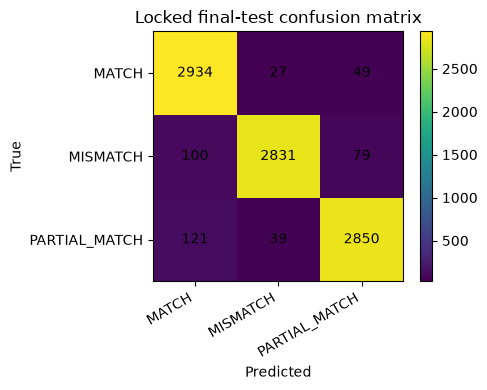

In [8]:
labels = final_summary['labels']
confusion = pd.DataFrame(final_summary['confusion_matrix'], index=labels, columns=labels)
display(confusion)

fig, ax = plt.subplots(figsize=(5, 4))
image = ax.imshow(confusion.values)
ax.set_xticks(range(len(labels)), labels, rotation=30, ha='right')
ax.set_yticks(range(len(labels)), labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Locked final-test confusion matrix')
for row in range(len(labels)):
    for col in range(len(labels)):
        ax.text(col, row, int(confusion.iloc[row, col]), ha='center', va='center')
fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## 7. Results for each class

The F1 scores for the three classes are close to each other. This tells me that the overall score is not high only because one class is easier or more common.


In [9]:
per_label = pd.DataFrame(final_summary['per_label']).T
per_label.index.name = 'label'
display(per_label[['precision', 'recall', 'f1', 'support']])

,precision,recall,f1,support
label,,,,
MATCH,0.929952,0.974751,0.951825,3010.0
MISMATCH,0.977218,0.940532,0.958524,3010.0
PARTIAL_MATCH,0.957018,0.946844,0.951904,3010.0


## 8. Looking at independent images

One image can appear in several image-text pairs, so the relation rows are not completely independent. I therefore also look at the result when every one of the 1,388 test images has equal weight.


In [10]:
image_metrics = sanity_audit['image_level_metrics']
image_table = pd.DataFrame({
    'value': [
        image_metrics['independent_images'],
        image_metrics['equal_weight_mean_relation_accuracy'],
        image_metrics['perfect_images'],
        image_metrics['perfect_image_fraction'],
        image_metrics['relations_per_image_min'],
        image_metrics['relations_per_image_median'],
        image_metrics['relations_per_image_max'],
    ]
}, index=[
    'independent_images',
    'equal_weight_mean_relation_accuracy',
    'perfect_images',
    'perfect_image_fraction',
    'relations_per_image_min',
    'relations_per_image_median',
    'relations_per_image_max',
])
display(image_table)

,value
independent_images,1388.000000
equal_weight_mean_relation_accuracy,0.955612
perfect_images,1207.000000
perfect_image_fraction,0.869597
relations_per_image_min,6.000000
relations_per_image_median,6.000000
relations_per_image_max,12.000000


## 9. Harder and easier categories

Some part categories are harder for the model than others. I show them separately because one overall accuracy number can hide these differences.


,independent_images,rows,accuracy,macro_f1
part_category,,,,
gas_cap,29,174,0.798851,0.789469
leaf_spring,18,186,0.822581,0.826100
transmission,26,180,0.861111,0.857918
fuel_injector,30,192,0.885417,0.883598
alternator,30,186,0.892473,0.890457
vacuum_brake_booster,28,180,0.894444,0.895705
side_mirror,29,174,0.908046,0.909660
camshaft,25,180,0.911111,0.910834
oxygen_sensor,29,174,0.913793,0.914075


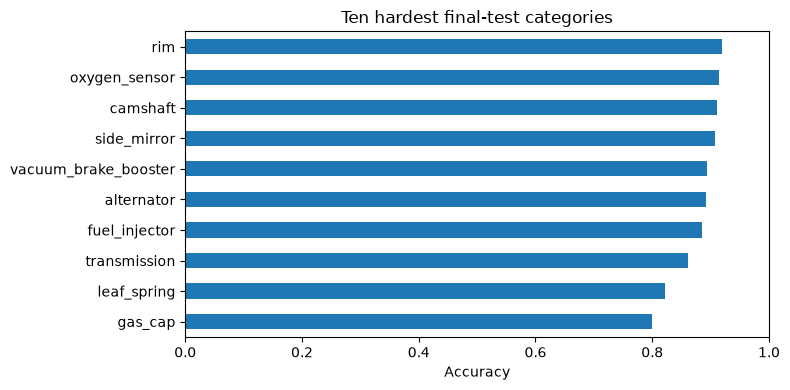

In [11]:
category_metrics = pd.DataFrame.from_dict(sanity_audit['category_metrics'], orient='index')
category_metrics.index.name = 'part_category'
hardest = category_metrics.sort_values('accuracy').head(10)
display(hardest[['independent_images', 'rows', 'accuracy', 'macro_f1']])

ax = hardest.sort_values('accuracy').plot.barh(y='accuracy', figsize=(8, 4), legend=False)
ax.set_xlim(0, 1)
ax.set_xlabel('Accuracy')
ax.set_ylabel('')
ax.set_title('Ten hardest final-test categories')
plt.tight_layout()
plt.show()

## 10. Error analysis

There are 415 wrong relation predictions in the saved final-test CSV. They come from 181 of the 1,388 independent test images, so the mistakes are concentrated in a smaller group of difficult images.


In [12]:
error_directions = (
    error_rows.groupby(['label', 'prediction'])
    .size()
    .reset_index(name='errors')
    .sort_values('errors', ascending=False)
)
by_image = (
    error_rows.groupby(['image_id', 'part_category'])
    .size()
    .reset_index(name='errors')
    .sort_values('errors', ascending=False)
)

print('Wrong relation predictions:', len(error_rows))
print('Independent images with at least one error:', by_image['image_id'].nunique())
display(error_directions)
display(by_image.head(10))

Wrong relation predictions: 415
Independent images with at least one error: 181


,label,prediction,errors
4,PARTIAL_MATCH,MATCH,121
2,MISMATCH,MATCH,100
3,MISMATCH,PARTIAL_MATCH,79
1,MATCH,PARTIAL_MATCH,49
5,PARTIAL_MATCH,MISMATCH,39
0,MATCH,MISMATCH,27


,image_id,part_category,errors
80,v4_leaf_spring_test_0004_29bba8f26a23b119,leaf_spring,12
158,v4_transmission_test_0009_25bf35275d107bd1,transmission,8
83,v4_leaf_spring_test_0018_5c622933f857c719,leaf_spring,7
45,v4_fuel_injector_test_0005_2f2a9ce1d8fde0cb,fuel_injector,6
28,v4_camshaft_test_0006_7cbcd712700e92d6,camshaft,6
79,v4_leaf_spring_test_0003_99814a47deae3c7d,leaf_spring,6
175,v4_water_pump_test_0020_24f41fe79a4b3eae,water_pump,6
109,v4_piston_test_0003_041cc1654e5b5838,piston,6
106,v4_oxygen_sensor_test_0027_df9cb5ae34907a2d,oxygen_sensor,6
88,v4_muffler_test_0002_09acce48324ef3e2,muffler,5


## 11. Check for visually similar images

Because the final score was high, I also checked for very similar images that may have landed in different splits. I found some candidates, so I report this as a limitation. However, when I remove all 37 flagged final-test images from the **already saved predictions**, the result stays almost the same.


In [13]:
sensitivity_rows = []
for level in ['very_strict', 'strict', 'screen']:
    item = sanity_audit['near_duplicate_screen']['sensitivity'][level]
    metrics = item['metrics_after_excluding_flagged_images']
    sensitivity_rows.append({
        'screen_level': level,
        'flagged_test_images': item['flagged_test_images'],
        'remaining_images': metrics['independent_images'],
        'remaining_rows': metrics['rows'],
        'accuracy': metrics['accuracy'],
        'macro_f1': metrics['macro_f1'],
    })

sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity)
print('Total candidate pairs:', sanity_audit['near_duplicate_screen']['candidate_pairs_total'])

,screen_level,flagged_test_images,remaining_images,remaining_rows,accuracy,macro_f1
0,very_strict,14,1374,8940,0.953915,0.953955
1,strict,22,1366,8883,0.953844,0.953884
2,screen,37,1351,8784,0.953552,0.953594


Total candidate pairs: 93


## 12. Final checks and what the result means

The final score is high, so I checked the data and saved predictions carefully. I did not find exact image overlap, exact description overlap, or an obvious input leakage.

My conclusion is limited to this project: **the model performs well on this prepared 50-category experiment**. This does not mean that it is ready for real customer use. I have not tested unknown categories, free-form customer descriptions, very difficult photos, or a completely separate external dataset.


In [14]:
checks = sanity_audit['code_leakage_checks']
assert sanity_audit['exact_split_overlap']['train_test_sha256'] == 0
assert sanity_audit['exact_split_overlap']['train_validation_sha256'] == 0
assert sanity_audit['exact_split_overlap']['validation_test_sha256'] == 0
assert sanity_audit['description_overlap'] == {
    'train_test': 0,
    'train_validation': 0,
    'validation_test': 0,
}
assert checks['model_receives_only_image_and_text'] is True
assert checks['tfidf_fit_on_development_only'] is True
assert final_summary['post_test_tuning_allowed'] is False
assert final_summary['selected_model'] == validation_summary['selected_model']
assert final_summary['final_training_epochs'] == validation_summary['selected_best_epoch']

print('PASS_DATASET_V4_REPORT_CHECKS')
print('No new training performed by this notebook: True')
print('No new final-test inference performed by this notebook: True')
print('Official final-test accuracy:', round(float(final_summary['final_test_accuracy']), 4))
print('Official final-test macro F1:', round(float(final_summary['final_test_macro_f1']), 4))

PASS_DATASET_V4_REPORT_CHECKS
No new training performed by this notebook: True
No new final-test inference performed by this notebook: True
Official final-test accuracy: 0.954
Official final-test macro F1: 0.9541
